<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
Overall non-repayment rate: 16.01%


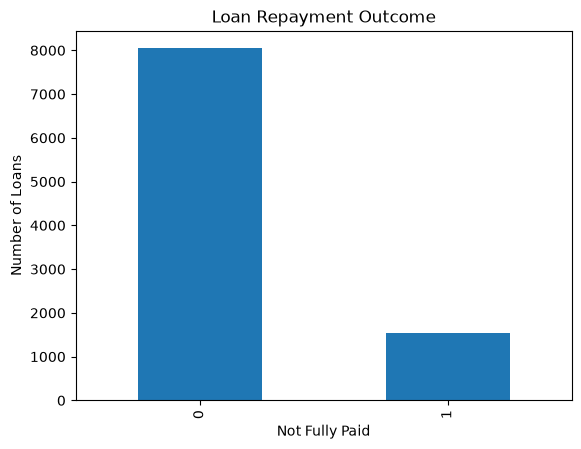

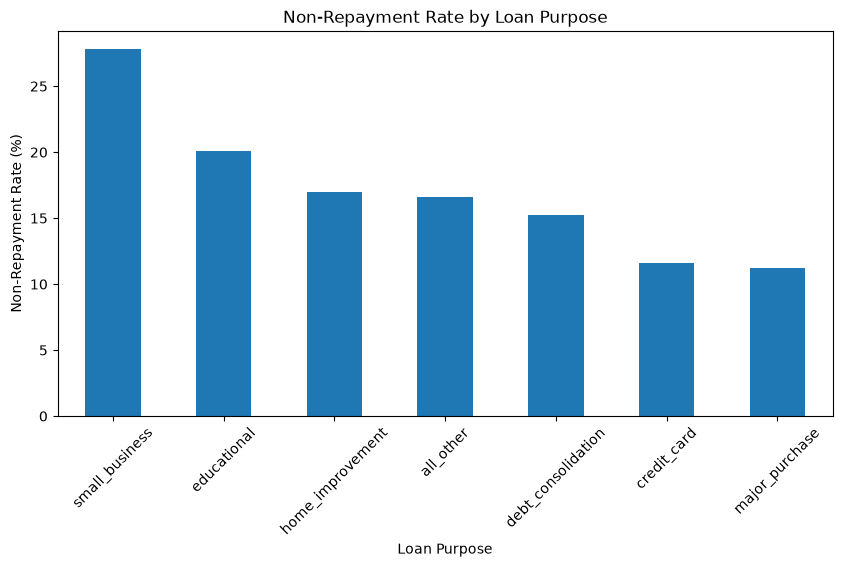

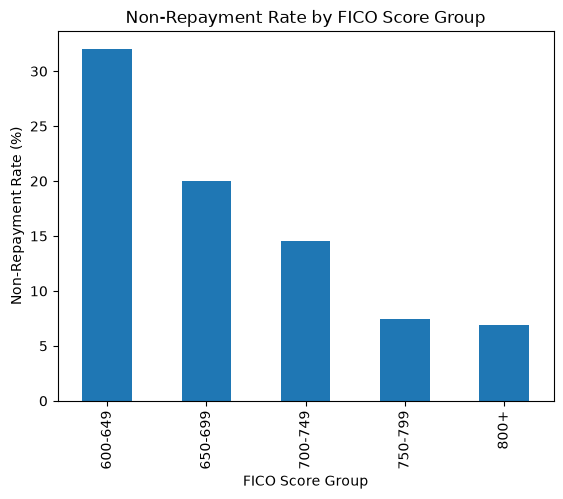

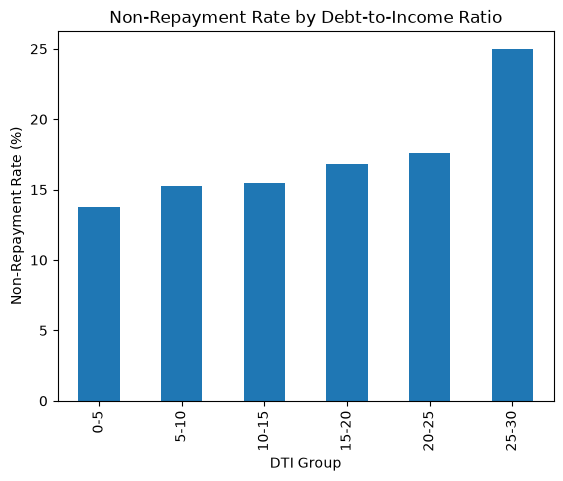

not.fully.paid
0    0.1218
1    0.1316
Name: int.rate, dtype: float64

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/Users/mihirmewada/Desktop/Loan Default Risk Analyzer/data/loan_data.csv"
)

df.head()
df.shape
df.columns
df.info()
df.isnull().sum()

missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

pd.DataFrame({"missing_count": missing, "missing_percentage": missing_percentage})

df.duplicated().sum()

df.describe()

df["fico"].describe()

df["dti"].describe()
df["installment"].describe()
df["not.fully.paid"].value_counts()
df["not.fully.paid"].value_counts(normalize=True) * 100
df["purpose"].value_counts()
df["purpose"].value_counts(normalize=True) * 100
default_rate = df["not.fully.paid"].mean() * 100

print(f"Overall non-repayment rate: {default_rate:.2f}%")

df["not.fully.paid"].value_counts().plot(kind="bar")

plt.title("Loan Repayment Outcome")
plt.xlabel("Not Fully Paid")
plt.ylabel("Number of Loans")

plt.show()

purpose_risk = (
    df.groupby("purpose")["not.fully.paid"].mean().sort_values(ascending=False) * 100
)

purpose_risk

purpose_risk.plot(kind="bar", figsize=(10, 5))

plt.title("Non-Repayment Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Non-Repayment Rate (%)")
plt.xticks(rotation=45)

plt.show()

df.groupby("not.fully.paid")["fico"].describe()
df["fico_group"] = pd.cut(
    df["fico"],
    bins=[0, 600, 650, 700, 750, 800, 850],
    labels=["<600", "600-649", "650-699", "700-749", "750-799", "800+"],
)

fico_risk = df.groupby("fico_group", observed=True)["not.fully.paid"].mean().mul(100)

fico_risk

fico_risk.plot(kind="bar")

plt.title("Non-Repayment Rate by FICO Score Group")
plt.xlabel("FICO Score Group")
plt.ylabel("Non-Repayment Rate (%)")

plt.show()

df["dti_group"] = pd.cut(
    df["dti"],
    bins=[0, 5, 10, 15, 20, 25, 30],
    labels=["0-5", "5-10", "10-15", "15-20", "20-25", "25-30"],
)

dti_risk = df.groupby("dti_group", observed=True)["not.fully.paid"].mean().mul(100)

dti_risk

dti_risk.plot(kind="bar")

plt.title("Non-Repayment Rate by Debt-to-Income Ratio")
plt.xlabel("DTI Group")
plt.ylabel("Non-Repayment Rate (%)")

plt.show()

df.groupby("not.fully.paid")["int.rate"].mean()

df.groupby("not.fully.paid")["int.rate"].median()

### Dataset Overview

The dataset contains loan-level information including:
- Credit policy status
- Loan purpose
- Interest rate
- Installment amount
- Borrower income
- Debt-to-income ratio
- FICO score
- Credit history
- Revolving credit information
- Credit inquiries
- Delinquencies
- Public records
- Loan repayment outcome